# IBM HR Employee Attrition: A Statistical Analysis

## Project goal

This notebook studies four meaningful questions in the employee dataset. Rather than applying the same test repeatedly, each question uses a method that fits the type of variables involved.

| Scenario | Research question | Method |
|---|---|---|
| 1 | Do employees who leave have shorter company tenure than employees who stay? | Mann–Whitney U + rank-biserial effect size |
| 2 | Is overtime work associated with employee attrition? | Chi-square + Cramér's V |
| 3 | Is total working experience related to monthly income? | Spearman correlation |
| 4 | Does monthly income differ across job roles? | Kruskal–Wallis + Dunn post-hoc |

### Significance level

Throughout the notebook, the significance level is:

```python
alpha = 0.05
```

A statistically significant relationship does not prove that one factor causes another. This dataset supports association-based conclusions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.stats import (
    shapiro,
    mannwhitneyu,
    chi2_contingency,
    spearmanr,
    kruskal,
    rankdata,
    norm
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda number: f"{number:,.4f}")

alpha = 0.05

## 1. Load and inspect the dataset

In [2]:
df = pd.read_csv("../data/IBM_HR_Employee_Attrition.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
print("Missing values in the dataset:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

constant_columns = [
    column for column in df.columns
    if df[column].nunique() == 1
]

print("Constant columns:", constant_columns)

df = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

print("Shape after removing ID and constant columns:", df.shape)

Missing values in the dataset: 0
Duplicate rows: 0
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Shape after removing ID and constant columns: (1470, 31)


### Overall attrition summary

`Attrition` is the central workplace outcome in this project. Before testing possible factors, we first check how many employees left and stayed.


In [4]:
attrition_summary = df["Attrition"].value_counts().rename_axis("Attrition").reset_index(name="Employees")
attrition_summary["Percentage"] = (
    attrition_summary["Employees"] / len(df) * 100
).round(1)

display(attrition_summary)

,Attrition,Employees,Percentage
0,No,1233,83.9000
1,Yes,237,16.1000


## 2. Scenario 1: Company tenure and attrition

### Research question

> Do employees who leave have shorter company tenure than employees who stay?

- Grouping variable: `Attrition` with two independent groups, Yes and No
- Outcome variable: `YearsAtCompany`
- Since tenure is non-normal inside both attrition groups, the appropriate comparison is the **Mann–Whitney U test**
- Effect size: **rank-biserial correlation**


In [5]:
left_tenure = df.loc[df["Attrition"] == "Yes", "YearsAtCompany"]
stayed_tenure = df.loc[df["Attrition"] == "No", "YearsAtCompany"]

tenure_normality = pd.DataFrame({
    "Group": ["Left the company", "Stayed with the company"],
    "N": [len(left_tenure), len(stayed_tenure)],
    "Median Years": [left_tenure.median(), stayed_tenure.median()],
    "Skewness": [left_tenure.skew(), stayed_tenure.skew()],
    "Shapiro p-value": [
        shapiro(left_tenure).pvalue,
        shapiro(stayed_tenure).pvalue
    ]
})

tenure_normality["Normally Distributed?"] = np.where(
    tenure_normality["Shapiro p-value"] >= alpha,
    "Yes",
    "No"
)

display(tenure_normality.round(4))

,Group,N,Median Years,Skewness,Shapiro p-value,Normally Distributed?
0,Left the company,237,3.0000,2.6822,0.0000,No
1,Stayed with the company,1233,6.0000,1.6580,0.0000,No


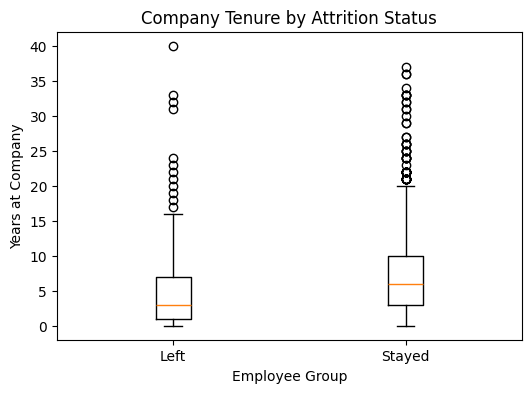

In [6]:
plt.figure(figsize=(6, 4))

plt.boxplot(
    [left_tenure, stayed_tenure],
    tick_labels=["Left", "Stayed"]
)

plt.title("Company Tenure by Attrition Status")
plt.xlabel("Employee Group")
plt.ylabel("Years at Company")
plt.show()

In [7]:
mann_whitney_result = mannwhitneyu(
    left_tenure,
    stayed_tenure,
    alternative="two-sided",
    method="asymptotic"
)

rank_biserial = (
    2 * mann_whitney_result.statistic /
    (len(left_tenure) * len(stayed_tenure))
) - 1

tenure_result = pd.DataFrame({
    "Test": ["Mann–Whitney U"],
    "Median: Left": [left_tenure.median()],
    "Median: Stayed": [stayed_tenure.median()],
    "U Statistic": [mann_whitney_result.statistic],
    "p-value": [mann_whitney_result.pvalue],
    "Rank-Biserial r": [rank_biserial],
    "Significant?": ["Yes" if mann_whitney_result.pvalue < alpha else "No"]
})

display(tenure_result.round(4))

,Test,Median: Left,Median: Stayed,U Statistic,p-value,Rank-Biserial r,Significant?
0,Mann–Whitney U,3.0000,6.0000,"102,582.0000",0.0000,-0.2979,Yes


### Interpretation

Employees who left the company had a median tenure of **3 years**, whereas employees who stayed had a median tenure of **6 years**. The difference is statistically significant, and the effect size is close to moderate. This suggests that retention challenges are more visible among employees with shorter organisational tenure.


## 3. Scenario 2: Overtime and attrition

### Research question

> Is overtime work associated with employee attrition?

Both variables are categorical:

- `OverTime`: Yes or No
- `Attrition`: Yes or No

Therefore, the suitable method is the **chi-square test of independence**.  
Cramér's V is added to report the strength of the association.


In [8]:
overtime_table = pd.crosstab(df["OverTime"], df["Attrition"])

overtime_rates = (
    pd.crosstab(df["OverTime"], df["Attrition"], normalize="index")
    .mul(100)
    .round(1)
)

display(overtime_table)
display(overtime_rates.rename(columns={"Yes": "Left (%)", "No": "Stayed (%)"}))

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


Attrition,Stayed (%),Left (%)
OverTime,,
No,89.6000,10.4000
Yes,69.5000,30.5000


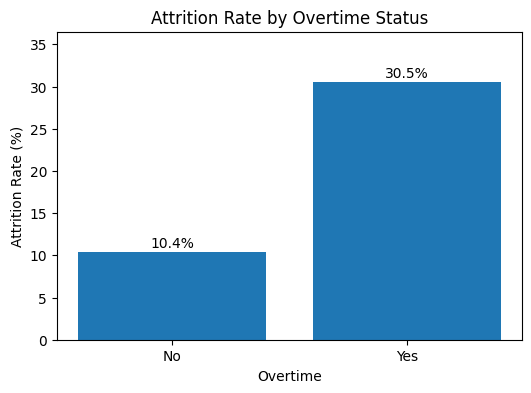

In [9]:
attrition_rate_by_overtime = overtime_rates["Yes"]

plt.figure(figsize=(6, 4))
plt.bar(attrition_rate_by_overtime.index, attrition_rate_by_overtime.values)

plt.title("Attrition Rate by Overtime Status")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

for position, value in enumerate(attrition_rate_by_overtime.values):
    plt.text(position, value + 0.6, f"{value:.1f}%", ha="center")

plt.ylim(0, attrition_rate_by_overtime.max() + 6)
plt.show()

In [10]:
chi_square_result = chi2_contingency(overtime_table)

chi_square = chi_square_result.statistic
chi_p_value = chi_square_result.pvalue
expected_counts = chi_square_result.expected_freq

n = overtime_table.to_numpy().sum()
cramers_v = np.sqrt(
    chi_square / (n * (min(overtime_table.shape) - 1))
)

risk_ratio = (
    attrition_rate_by_overtime["Yes"] /
    attrition_rate_by_overtime["No"]
)

chi_square_summary = pd.DataFrame({
    "Test": ["Chi-square test"],
    "Chi-square Statistic": [chi_square],
    "p-value": [chi_p_value],
    "Cramer's V": [cramers_v],
    "Minimum Expected Count": [expected_counts.min()],
    "Significant?": ["Yes" if chi_p_value < alpha else "No"]
})

display(chi_square_summary.round(4))
print("Attrition rate risk ratio:", round(risk_ratio, 2))

,Test,Chi-square Statistic,p-value,Cramer's V,Minimum Expected Count,Significant?
0,Chi-square test,87.5643,0.0000,0.2441,67.0694,Yes


Attrition rate risk ratio: 2.93


### Interpretation

Employees working overtime had an attrition rate of **30.5%**, compared with **10.4%** among employees who did not work overtime. The association is statistically significant with a meaningful Cramér's V effect size. In practical terms, the attrition rate among overtime workers is about **2.93 times** the rate among non-overtime workers.


## 4. Scenario 3: Work experience and monthly income

### Research question

> Is total working experience related to monthly income?

Both variables are numerical. Since they are not normally distributed, a non-parametric correlation is appropriate:

- Variable 1: `TotalWorkingYears`
- Variable 2: `MonthlyIncome`
- Method: **Spearman rank correlation**


In [11]:
experience = df["TotalWorkingYears"]
income = df["MonthlyIncome"]

correlation_normality = pd.DataFrame({
    "Variable": ["Total Working Years", "Monthly Income"],
    "Skewness": [experience.skew(), income.skew()],
    "Shapiro p-value": [
        shapiro(experience).pvalue,
        shapiro(income).pvalue
    ]
})

correlation_normality["Normally Distributed?"] = np.where(
    correlation_normality["Shapiro p-value"] >= alpha,
    "Yes",
    "No"
)

display(correlation_normality.round(4))

,Variable,Skewness,Shapiro p-value,Normally Distributed?
0,Total Working Years,1.1172,0.0000,No
1,Monthly Income,1.3698,0.0000,No


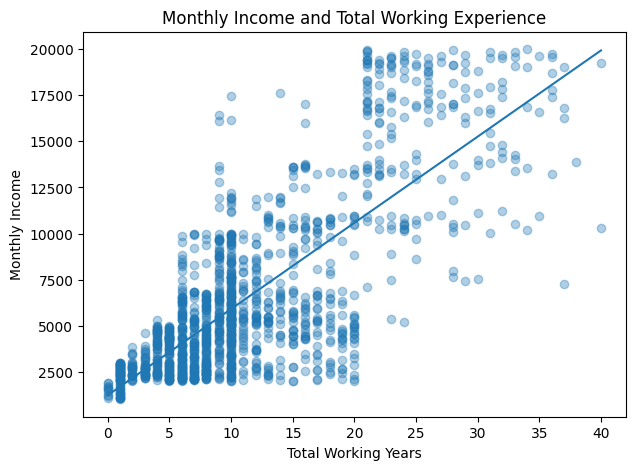

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(experience, income, alpha=0.35)

trend_values = np.polyfit(experience, income, 1)
trend_line = np.poly1d(trend_values)
ordered_experience = experience.sort_values()

plt.plot(ordered_experience, trend_line(ordered_experience))

plt.title("Monthly Income and Total Working Experience")
plt.xlabel("Total Working Years")
plt.ylabel("Monthly Income")
plt.show()

In [13]:
spearman_result = spearmanr(experience, income)

spearman_summary = pd.DataFrame({
    "Test": ["Spearman Correlation"],
    "Variable 1": ["TotalWorkingYears"],
    "Variable 2": ["MonthlyIncome"],
    "Spearman rho": [spearman_result.statistic],
    "p-value": [spearman_result.pvalue],
    "Significant?": ["Yes" if spearman_result.pvalue < alpha else "No"]
})

display(spearman_summary.round(4))

,Test,Variable 1,Variable 2,Spearman rho,p-value,Significant?
0,Spearman Correlation,TotalWorkingYears,MonthlyIncome,0.7100,0.0000,Yes


### Interpretation

There is a strong positive and statistically significant relationship between total working experience and monthly income. Employees with more years of overall work experience generally have higher monthly salaries.


## 5. Scenario 4: Job role and monthly income

### Research question

> Does monthly income differ across job roles?

- Grouping variable: `JobRole`, containing more than two independent groups
- Outcome variable: `MonthlyIncome`
- Monthly income is skewed, so the suitable test is **Kruskal–Wallis**
- When the overall test is significant, **Dunn post-hoc comparisons with Holm adjustment** identify which role pairs differ


In [14]:
role_income_summary = (
    df.groupby("JobRole")["MonthlyIncome"]
    .agg(Employees="count", Median_Income="median", Mean_Income="mean")
    .sort_values("Median_Income")
)

display(role_income_summary.round(2))

,Employees,Median_Income,Mean_Income
JobRole,,,
Sales Representative,83,"2,579.0000","2,626.0000"
Laboratory Technician,259,"2,886.0000","3,237.1700"
Research Scientist,292,"2,887.5000","3,239.9700"
Human Resources,52,"3,093.0000","4,235.7500"
Sales Executive,326,"6,231.0000","6,924.2800"
Manufacturing Director,145,"6,447.0000","7,295.1400"
Healthcare Representative,131,"6,811.0000","7,528.7600"
Research Director,80,"16,510.0000","16,033.5500"
Manager,102,"17,454.5000","17,181.6800"


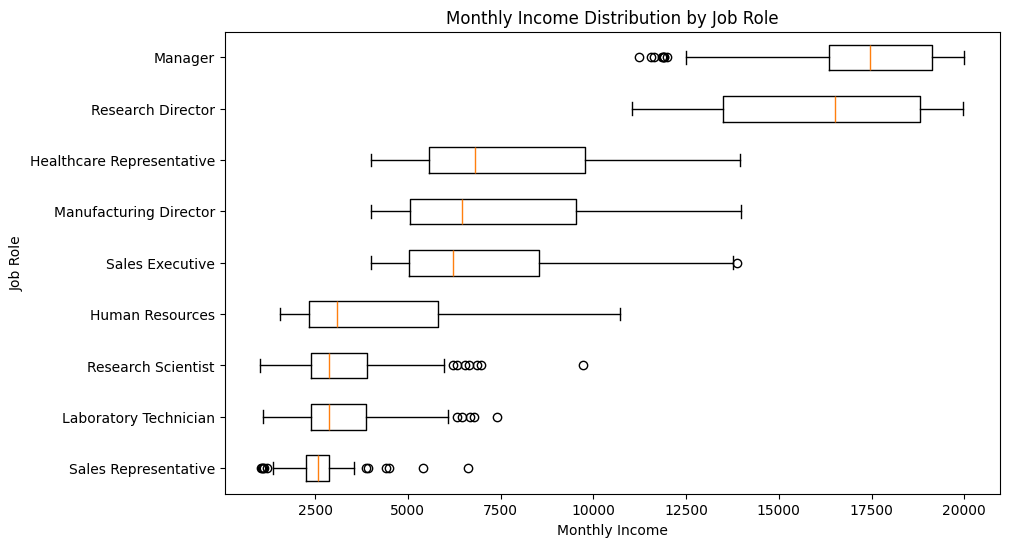

In [15]:
role_order = role_income_summary.index.tolist()

income_groups = [
    df.loc[df["JobRole"] == role, "MonthlyIncome"]
    for role in role_order
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    income_groups,
    tick_labels=role_order,
    vert=False
)

plt.title("Monthly Income Distribution by Job Role")
plt.xlabel("Monthly Income")
plt.ylabel("Job Role")
plt.show()

In [16]:
kruskal_result = kruskal(*income_groups)

epsilon_squared = (
    (kruskal_result.statistic - len(role_order) + 1) /
    (len(df) - len(role_order))
)

kruskal_summary = pd.DataFrame({
    "Test": ["Kruskal–Wallis"],
    "Number of Job Roles": [len(role_order)],
    "H Statistic": [kruskal_result.statistic],
    "p-value": [kruskal_result.pvalue],
    "Epsilon-Squared": [epsilon_squared],
    "Significant?": ["Yes" if kruskal_result.pvalue < alpha else "No"]
})

display(kruskal_summary.round(4))

,Test,Number of Job Roles,H Statistic,p-value,Epsilon-Squared,Significant?
0,Kruskal–Wallis,9,"1,073.4101",0.0000,0.7292,Yes


### Dunn post-hoc test with Holm correction

Kruskal–Wallis tells us that at least one job role differs in monthly income, but it does not tell us which roles differ. The following small helper function carries out pairwise Dunn comparisons and applies Holm correction so that we do not overstate significance after testing many pairs.


In [17]:
def dunn_posthoc_holm(data, group_col, outcome_col):
    clean_data = data[[group_col, outcome_col]].dropna().copy()
    clean_data["Rank"] = rankdata(clean_data[outcome_col])

    total_n = len(clean_data)
    groups = clean_data[group_col].unique()

    group_counts = clean_data.groupby(group_col).size()
    mean_ranks = clean_data.groupby(group_col)["Rank"].mean()

    ties = clean_data[outcome_col].value_counts()
    tie_sum = ((ties ** 3) - ties).sum()

    rank_variance = (
        total_n * (total_n + 1) / 12
        - tie_sum / (12 * (total_n - 1))
    )

    comparisons = []

    for group_1, group_2 in combinations(groups, 2):
        denominator = np.sqrt(
            rank_variance *
            (1 / group_counts[group_1] + 1 / group_counts[group_2])
        )

        z_value = (
            mean_ranks[group_1] - mean_ranks[group_2]
        ) / denominator

        p_value = 2 * norm.sf(abs(z_value))

        comparisons.append({
            "Group 1": group_1,
            "Group 2": group_2,
            "z": z_value,
            "p-value": p_value
        })

    results = pd.DataFrame(comparisons).sort_values("p-value").reset_index(drop=True)

    number_of_tests = len(results)
    adjusted_values = []

    for index, p_value in enumerate(results["p-value"]):
        adjusted_values.append(
            min((number_of_tests - index) * p_value, 1)
        )

    results["Adjusted p-value"] = np.maximum.accumulate(adjusted_values)
    results["Significant after Holm?"] = np.where(
        results["Adjusted p-value"] < alpha,
        "Yes",
        "No"
    )

    return results


dunn_results = dunn_posthoc_holm(
    data=df,
    group_col="JobRole",
    outcome_col="MonthlyIncome"
)

significant_dunn_results = dunn_results[
    dunn_results["Significant after Holm?"] == "Yes"
]

print("Number of significant pairwise differences:", len(significant_dunn_results))
display(significant_dunn_results.round(4))

Number of significant pairwise differences: 27


,Group 1,Group 2,z,p-value,Adjusted p-value,Significant after Holm?
0,Research Scientist,Manager,-20.5471,0.0000,0.0000,Yes
1,Laboratory Technician,Manager,-20.2427,0.0000,0.0000,Yes
2,Research Scientist,Research Director,-18.2765,0.0000,0.0000,Yes
3,Laboratory Technician,Research Director,-18.0552,0.0000,0.0000,Yes
4,Manager,Sales Representative,17.9813,0.0000,0.0000,Yes
5,Sales Representative,Research Director,-16.6022,0.0000,0.0000,Yes
6,Sales Executive,Research Scientist,16.1414,0.0000,0.0000,Yes
7,Sales Executive,Laboratory Technician,15.6617,0.0000,0.0000,Yes
8,Research Scientist,Healthcare Representative,-13.6251,0.0000,0.0000,Yes
9,Laboratory Technician,Healthcare Representative,-13.3926,0.0000,0.0000,Yes


### Interpretation

Monthly income differs significantly across job roles. The median-income table makes the pattern clear: lower-paid roles include Sales Representative, Laboratory Technician and Research Scientist, while Manager and Research Director have the highest median monthly income. Dunn's post-hoc results show the specific pairs that remain significantly different after correcting for multiple comparisons.


## 6. Final findings summary

In [18]:
final_summary = pd.DataFrame({
    "Business Question": [
        "Does company tenure differ by attrition?",
        "Is overtime associated with attrition?",
        "Is work experience related to income?",
        "Does income differ across job roles?"
    ],
    "Method": [
        "Mann–Whitney U",
        "Chi-square",
        "Spearman correlation",
        "Kruskal–Wallis + Dunn"
    ],
    "Main Statistical Result": [
        f"U = {mann_whitney_result.statistic:.0f}, p < 0.001, r = {rank_biserial:.3f}",
        f"χ² = {chi_square:.2f}, p < 0.001, V = {cramers_v:.3f}",
        f"ρ = {spearman_result.statistic:.3f}, p < 0.001",
        f"H = {kruskal_result.statistic:.2f}, p < 0.001, ε² = {epsilon_squared:.3f}"
    ],
    "Meaning": [
        "Employees who left had shorter median tenure: 3 vs 6 years.",
        "Overtime employees had 30.5% attrition compared with 10.4% without overtime.",
        "Greater overall experience is strongly related to higher monthly income.",
        "Monthly income differs substantially across job roles."
    ]
})

display(final_summary)

,Business Question,Method,Main Statistical Result,Meaning
0,Does company tenure differ by attrition?,Mann–Whitney U,"U = 102582, p < 0.001, r = -0.298",Employees who left had shorter median tenure: ...
1,Is overtime associated with attrition?,Chi-square,"χ² = 87.56, p < 0.001, V = 0.244",Overtime employees had 30.5% attrition compare...
2,Is work experience related to income?,Spearman correlation,"ρ = 0.710, p < 0.001",Greater overall experience is strongly related...
3,Does income differ across job roles?,Kruskal–Wallis + Dunn,"H = 1073.41, p < 0.001, ε² = 0.729",Monthly income differs substantially across jo...


## Conclusion

This analysis identifies four meaningful patterns in the employee data:

1. Employees who left tended to have shorter company tenure than those who stayed.
2. Overtime was strongly associated with attrition, with overtime employees leaving at nearly three times the rate of non-overtime employees.
3. Total working experience was strongly positively related to monthly income.
4. Monthly income varied substantially across job roles.

The findings should be treated as associations rather than proof of cause. However, they point toward practical areas for further HR investigation, particularly early-tenure retention and overtime workload.
